**DSCB230 Sommersemester 2026**

# Hausarbeit - Unternehmensanalyse anhand des Aktienkurses
Data Science Portfolioprojekt

Gruppe | Studierende 1 | Studierende 2 |
------ | ------ | ------ |
`Foxtrot` | `Ivan Pedzin` | `Maximilian Hutter` |

## Business Case

Es sollen verschiedene Unternehmen, am Beispiel Apple, Microsoft und Samsung, auf Basis ihres Aktienkurses verglichen werden, um Investitionsentscheidungen zu treffen (Zeitraum 2000 - Jetzt). Alle Kurse werden in US-Dollar (USD) betrachtet, da die zugrunde liegenden Aktien an US-Börsen notieren.

Dabei werden speziell folgende Punkte untersucht:
- Allgemeiner grafischer Vergleich der Aktienkurse
- Rendite
- Volatilität
- gleitende Durchschnitte
- Verhalten in Krisenzeiten
- Am Beispiel Intel: Entwicklung einer Investition von 1.000 USD vom 04.05.2026 (2. Zwischenpräsentation) bis zur Abschlusspräsentation

## Datenerfassung und Datenvorverarbeitung

### Download des Datensatzes (Yahoo Finance API)

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd

heute = datetime.now().strftime('%Y-%m-%d')

# Aktien Dictionary, weitere Aktien einfach ergänzen
aktien = {
    "Apple":     "AAPL",
    "Microsoft": "MSFT",
    "Samsung":   "SMSN.IL"
}

In [2]:
# Daten von 2000
daten = {}
for name, ticker in aktien.items():
    daten[name] = yf.Ticker(ticker).history(start="2000-01-01", end=heute)

### Erster Überblick über die Daten

In [3]:
for name, df in daten.items():
    print(name)
    display(df.head())

Apple


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2000-01-03 00:00:00-05:00,0.784870,0.841934,0.761015,0.837724,535796800,0.0,0.0
2000-01-04 00:00:00-05:00,0.810128,0.827901,0.757273,0.767096,512377600,0.0,0.0
2000-01-05 00:00:00-05:00,0.776450,0.827434,0.770837,0.778321,778321600,0.0,0.0
2000-01-06 00:00:00-05:00,0.794225,0.800773,0.710966,0.710966,767972800,0.0,0.0
2000-01-07 00:00:00-05:00,0.722192,0.755870,0.714709,0.744644,460734400,0.0,0.0


Microsoft


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2000-01-03 00:00:00-05:00,35.690675,36.070767,34.056278,35.443615,53228400,0.0,0.0
2000-01-04 00:00:00-05:00,34.531388,35.614651,34.132291,34.246319,54119000,0.0,0.0
2000-01-05 00:00:00-05:00,33.790212,35.386600,33.258083,34.607410,64059600,0.0,0.0
2000-01-06 00:00:00-05:00,34.113297,34.626422,32.954015,33.448135,54976600,0.0,0.0
2000-01-07 00:00:00-05:00,33.030023,34.132291,32.630926,33.885231,62013600,0.0,0.0


Samsung


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2001-05-14 00:00:00+01:00,63.990933,63.990933,63.094701,63.453194,197500,0.0,0.0
2001-05-15 00:00:00+01:00,62.549760,63.596557,62.377685,62.599949,122000,0.0,0.0
2001-05-16 00:00:00+01:00,61.660723,62.571292,60.585246,60.764492,278900,0.0,0.0
2001-05-17 00:00:00+01:00,63.818860,64.442633,62.377718,64.163010,364300,0.0,0.0
2001-05-18 00:00:00+01:00,63.202255,64.528677,60.864881,64.119995,199100,0.0,0.0


### Datenbereinigung

#### Fehlende Werte prüfen

In [4]:
for name, df in daten.items():
    print(f'{name}:')
    print(df.isnull().sum())
#mit isnull schauen ob zellen leer sind und ergebnis (True/False) aller zellen zusammenrechnen

Apple:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64
Microsoft:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64
Samsung:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


#### Duplikate prüfen

In [5]:
for name, df in daten.items():
    print(f'{name}: {df.index.duplicated().sum()} Duplikate')
# schaut ob ein datum (index) doppelt vorkommt

Apple: 0 Duplikate
Microsoft: 0 Duplikate
Samsung: 0 Duplikate


#### Samsung-GDR in Einzelaktien umrechnen

In [6]:
# Samsung Kurse durch 25 teilen (GDR → Einzelaktie: 1 GDR = 25 Stammaktien)
for col in ["Close", "Open", "High", "Low"]:
    daten["Samsung"][col] = daten["Samsung"][col] / 25

#### Ausreißer prüfen (extreme Tagesrenditen)

Neben fehlenden Werten und Duplikaten prüfen wir die Tagesrenditen auf Ausreißer. Der Boxplot zeigt, wie weit einzelne Handelstage vom typischen Wertebereich abweichen. Sehr große Ausschläge sind hier in der Regel keine Datenfehler, sondern reale Marktereignisse (z. B. Crashs oder starke Kurssprünge) und werden daher bewusst beibehalten.

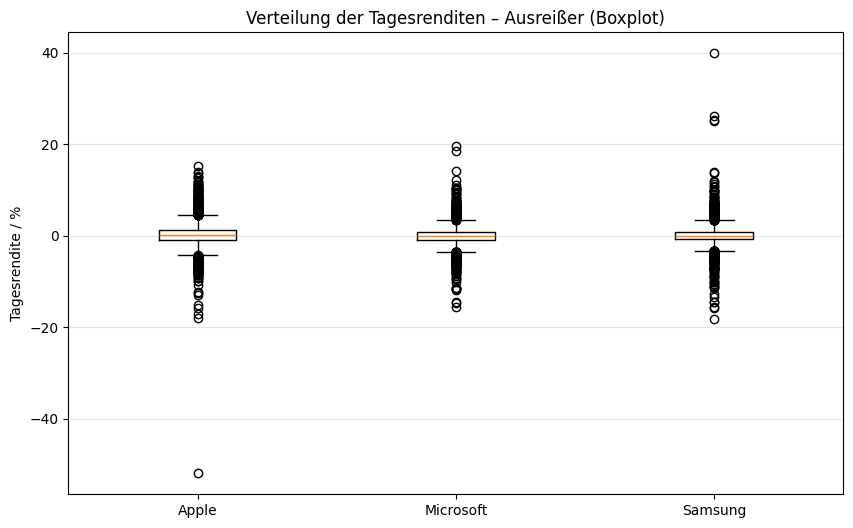

Apple: 411 Ausreißer-Tage | stärkster Tagesverlust -51.87% am 2000-09-29 | stärkster Tagesgewinn 15.33% am 2025-04-09
Microsoft: 406 Ausreißer-Tage | stärkster Tagesverlust -15.60% am 2000-04-24 | stärkster Tagesgewinn 19.57% am 2000-10-19
Samsung: 572 Ausreißer-Tage | stärkster Tagesverlust -18.09% am 2008-09-02 | stärkster Tagesgewinn 39.88% am 2009-08-25


In [7]:
# Tagesrenditen für die Ausreißerprüfung (in %)
renditen = {name: df["Close"].pct_change().dropna() * 100 for name, df in daten.items()}

plt.figure(figsize=(10, 6))
plt.boxplot(list(renditen.values()), showfliers=True)
plt.xticks(range(1, len(renditen) + 1), list(renditen.keys()))
plt.title("Verteilung der Tagesrenditen – Ausreißer (Boxplot)")
plt.ylabel("Tagesrendite / %")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Anzahl der Ausreißer je Unternehmen nach der IQR-Methode + stärkste Ausschläge
for name, r in renditen.items():
    q1, q3 = r.quantile(0.25), r.quantile(0.75)
    iqr = q3 - q1
    untergrenze, obergrenze = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    ausreisser = r[(r < untergrenze) | (r > obergrenze)]
    print(f"{name}: {len(ausreisser)} Ausreißer-Tage | "
          f"stärkster Tagesverlust {r.min():.2f}% am {r.idxmin().date()} | "
          f"stärkster Tagesgewinn {r.max():.2f}% am {r.idxmax().date()}")

## Analyse der Daten

### Kursvergleiche

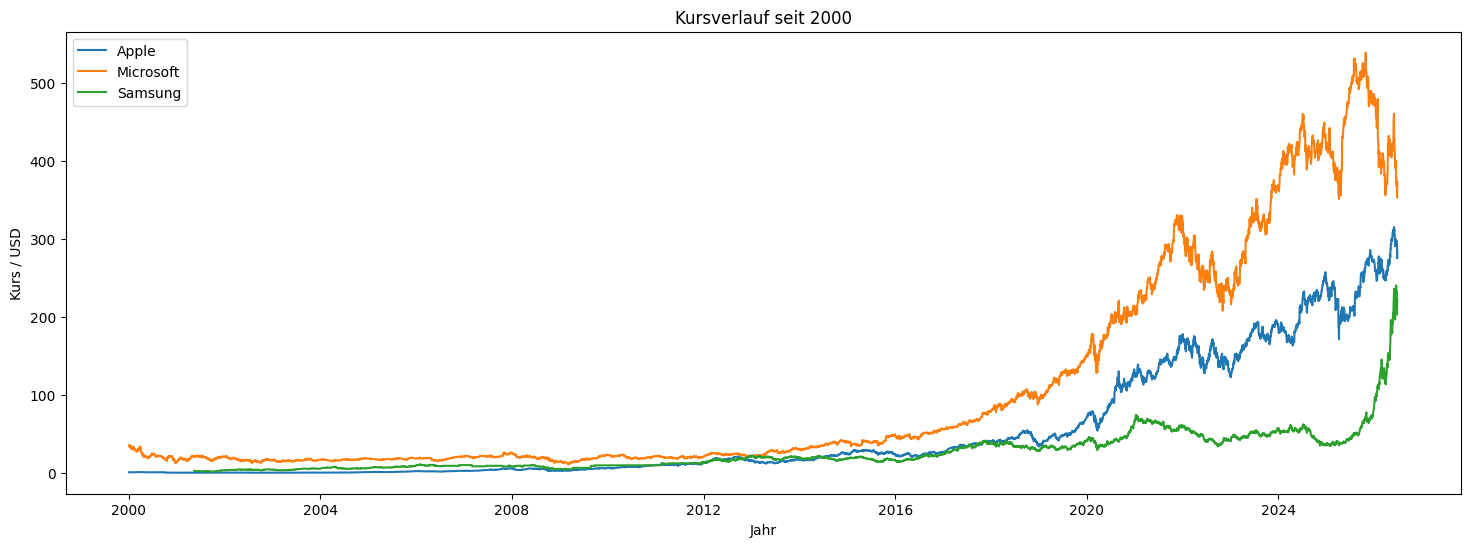

In [8]:
plt.figure(figsize=(18, 6))
for name, df in daten.items():
    plt.plot(df["Close"], label=name)
plt.title("Kursverlauf seit 2000")
plt.xlabel("Jahr")
plt.ylabel("Kurs / USD")
plt.legend()
plt.show()


**Interpretation:** Apple und Microsoft zeigen über den gesamten Zeitraum einen klaren langfristigen Aufwärtstrend, der sich vor allem ab etwa 2010 stark beschleunigt. Samsung bewegt sich auf einem deutlich niedrigeren absoluten Kursniveau. Da die Aktien zu unterschiedlichen Preisen notieren, ist der absolute Kursvergleich nur bedingt aussagekräftig – für einen fairen Vergleich der Wertentwicklung werden die Kurse weiter unten auf einen gemeinsamen Startwert normiert.

### Rendite

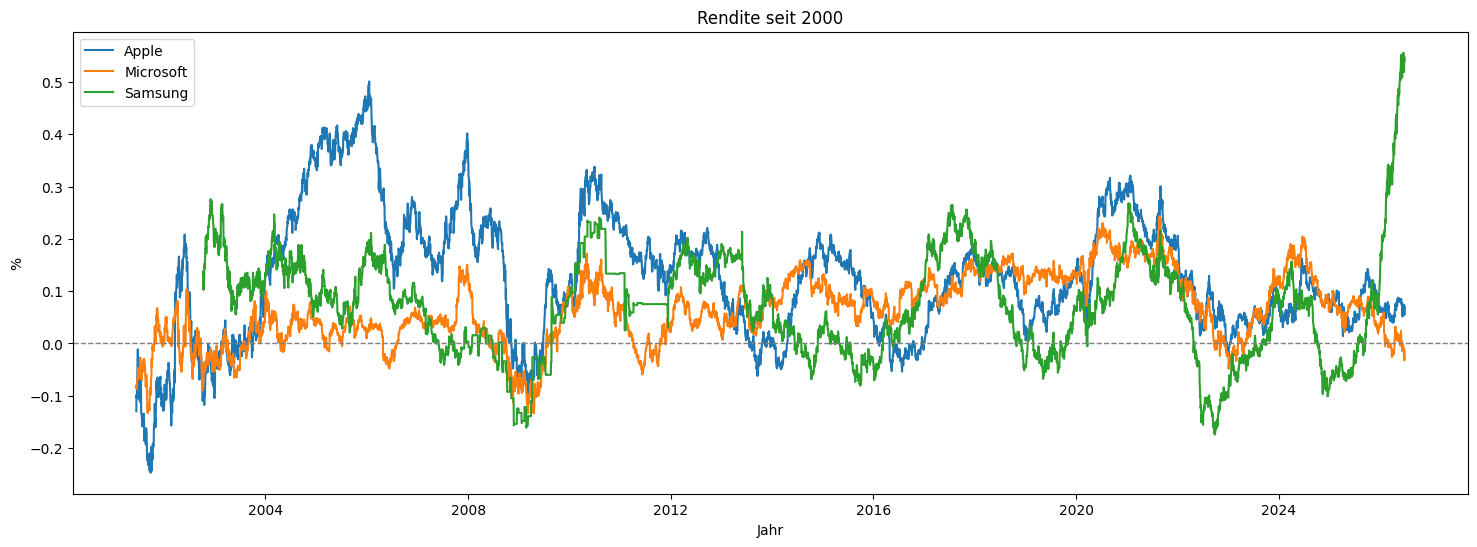

In [9]:
for name, df in daten.items():
    daten[name]["Rendite"] = daten[name]["Close"].pct_change() * 100

plt.figure(figsize=(18, 6))
for name, df in daten.items():
    plt.plot(df["Rendite"].rolling(365).mean(), label=name) #gleitender 365-Tage-Durchschnitt
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Rendite seit 2000")
plt.xlabel("Jahr")
plt.ylabel("%")
plt.legend()
plt.show()

**Interpretation:** Dargestellt ist der gleitende Jahresdurchschnitt (365 Tage) der täglichen Rendite. Die mittleren Tagesrenditen aller drei Unternehmen liegen nahe null und im langfristigen Mittel im positiven Bereich, was den grundsätzlichen Wertzuwachs widerspiegelt. Deutlich sichtbar sind Einbrüche in den Krisenphasen (u. a. 2000, 2008, 2020), in denen die durchschnittliche Rendite zeitweise negativ wird. Die tägliche Rendite selbst schwankt stark – erst die Glättung macht den Trend erkennbar.

### Volatilität

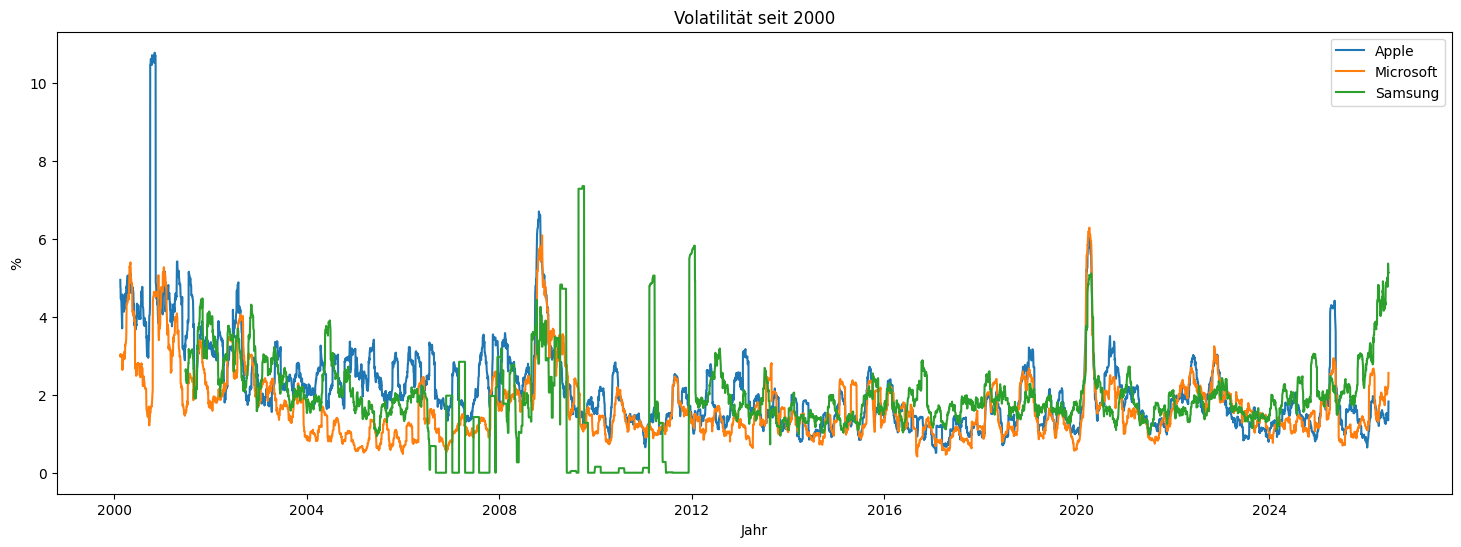

In [10]:
for name, df in daten.items():
    daten[name]["Volatilitaet"] = daten[name]["Rendite"].rolling(30).std() 

plt.figure(figsize=(18, 6))
for name, df in daten.items():
    plt.plot(df["Volatilitaet"], label=name)
plt.title("Volatilität seit 2000")
plt.xlabel("Jahr")
plt.ylabel("%")
plt.legend()
plt.show()

**Interpretation:** Die Volatilität (30-Tage-Standardabweichung der Tagesrendite) misst das Risiko bzw. die Schwankungsintensität. Auffällig sind die ausgeprägten Spitzen in den Krisenzeiträumen – insbesondere während der Finanzkrise 2008 und des Corona-Crashs im Frühjahr 2020 –, in denen das Risiko sprunghaft ansteigt. In ruhigen Marktphasen liegt die Volatilität dagegen auf einem niedrigen, stabilen Niveau. Samsung weist tendenziell die größten Ausschläge auf, was den Eindruck des höchsten Risikos aus der Ausreißer- und Krisenanalyse bestätigt.

### Gleitender Durchschnitt

#### Einfacher gleitender Durchschnitt (SMA)

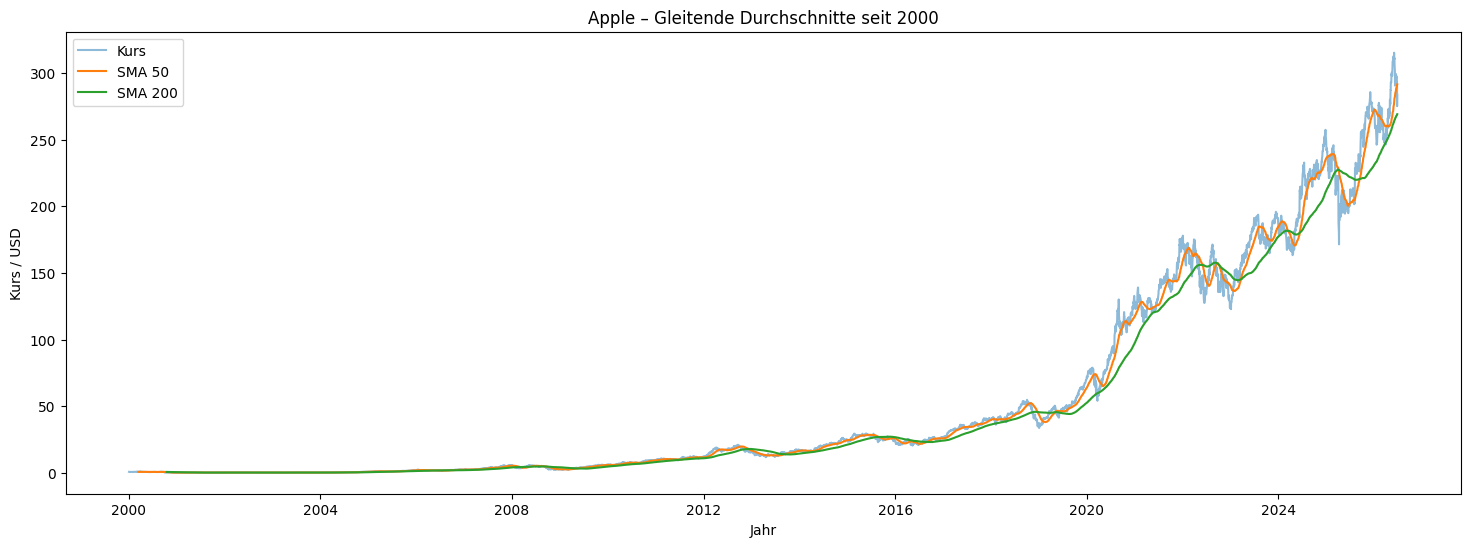

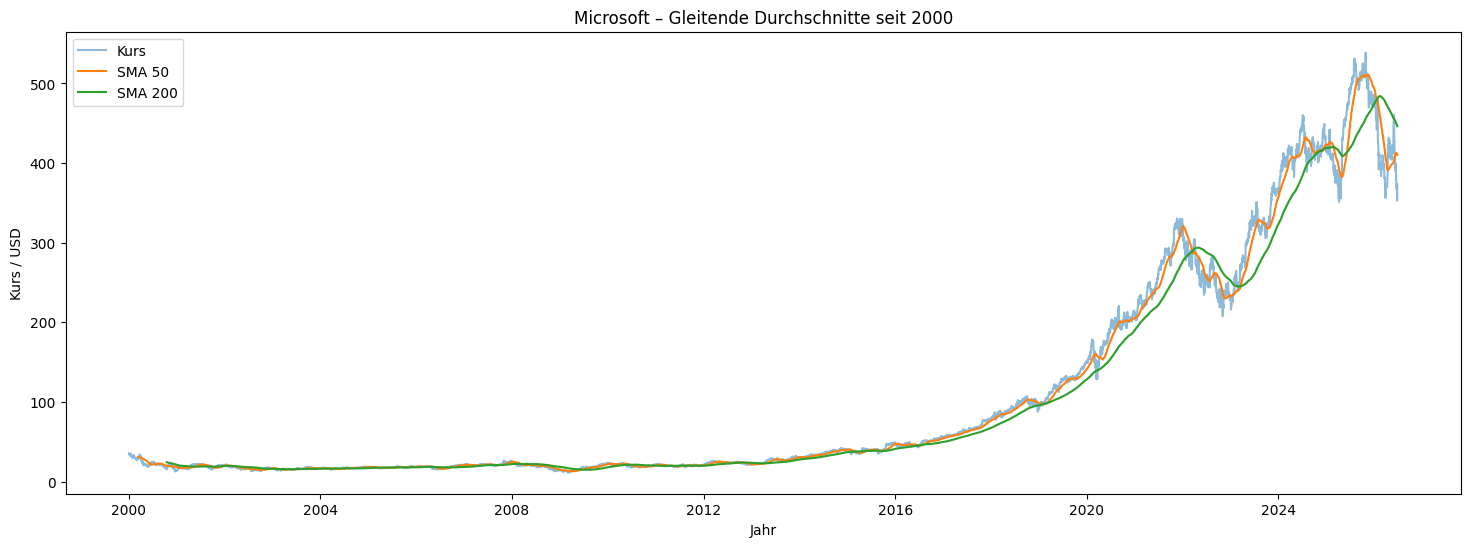

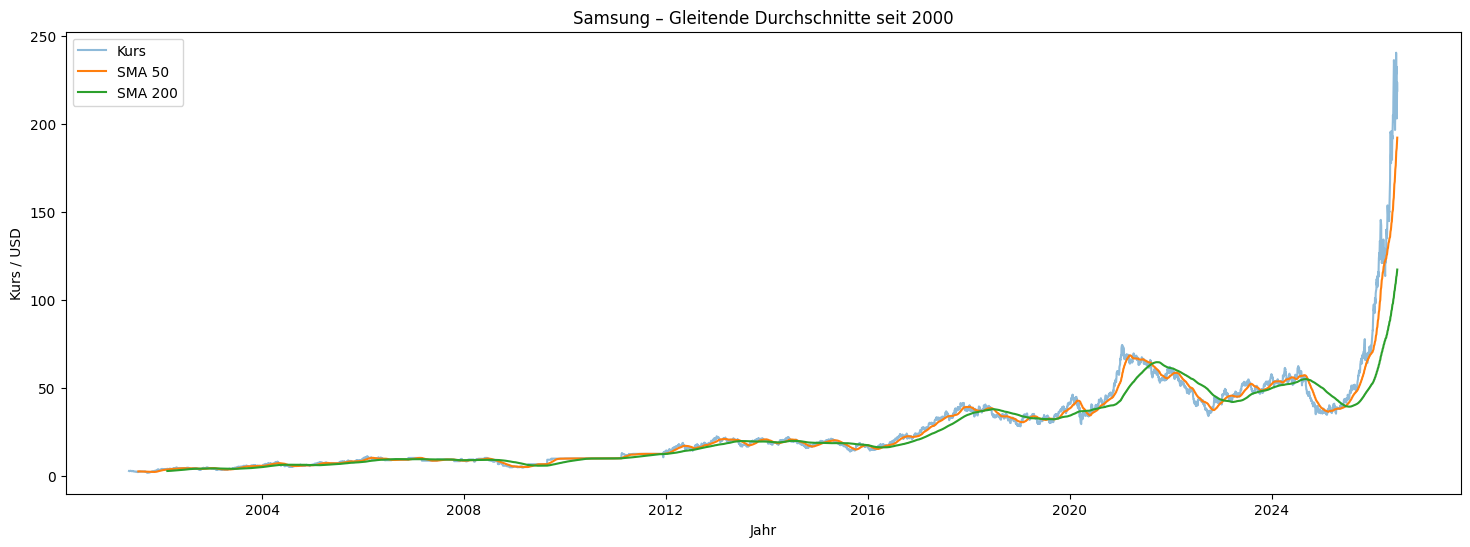

In [11]:
for name, df in daten.items():
    daten[name]["SMA_50"] = daten[name]["Close"].rolling(50).mean()
    daten[name]["SMA_200"] = daten[name]["Close"].rolling(200).mean()

for name, df in daten.items():
    plt.figure(figsize=(18, 6))
    plt.plot(df["Close"], label="Kurs", alpha=0.5)
    plt.plot(df["SMA_50"], label="SMA 50")
    plt.plot(df["SMA_200"], label="SMA 200")
    plt.title(f"{name} – Gleitende Durchschnitte seit 2000")
    plt.xlabel("Jahr")
    plt.ylabel("Kurs / USD")
    plt.legend()
    plt.show()

**Interpretation:** Der SMA 50 (kurzfristig) und der SMA 200 (langfristig) glätten den Kursverlauf und machen den übergeordneten Trend sichtbar. Liegt der Kurs über dem SMA 200, befindet sich die Aktie in einem langfristigen Aufwärtstrend; Schnittpunkte der beiden Linien signalisieren mögliche Trendwechsel (Kreuzung des SMA 50 über den SMA 200 als „Golden Cross", darunter als „Death Cross"). Bei Apple und Microsoft verläuft der Kurs über lange Strecken oberhalb des SMA 200, was den stabilen Aufwärtstrend unterstreicht.

#### Exponentieller gleitender Durchschnitt (EMA)

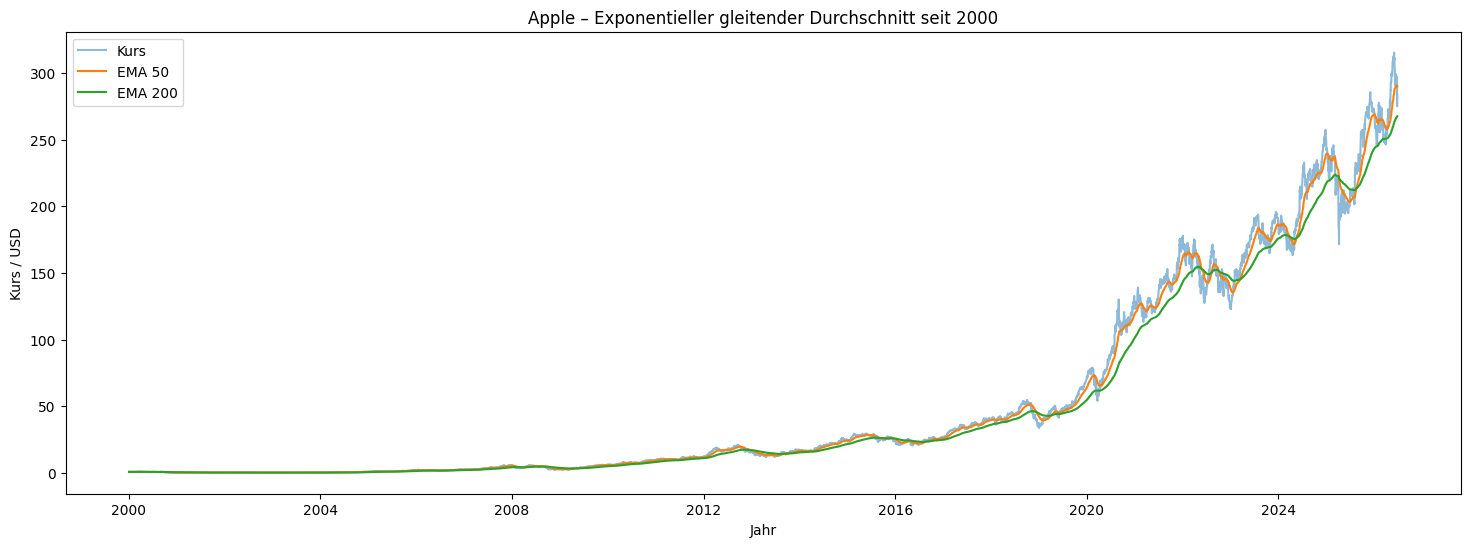

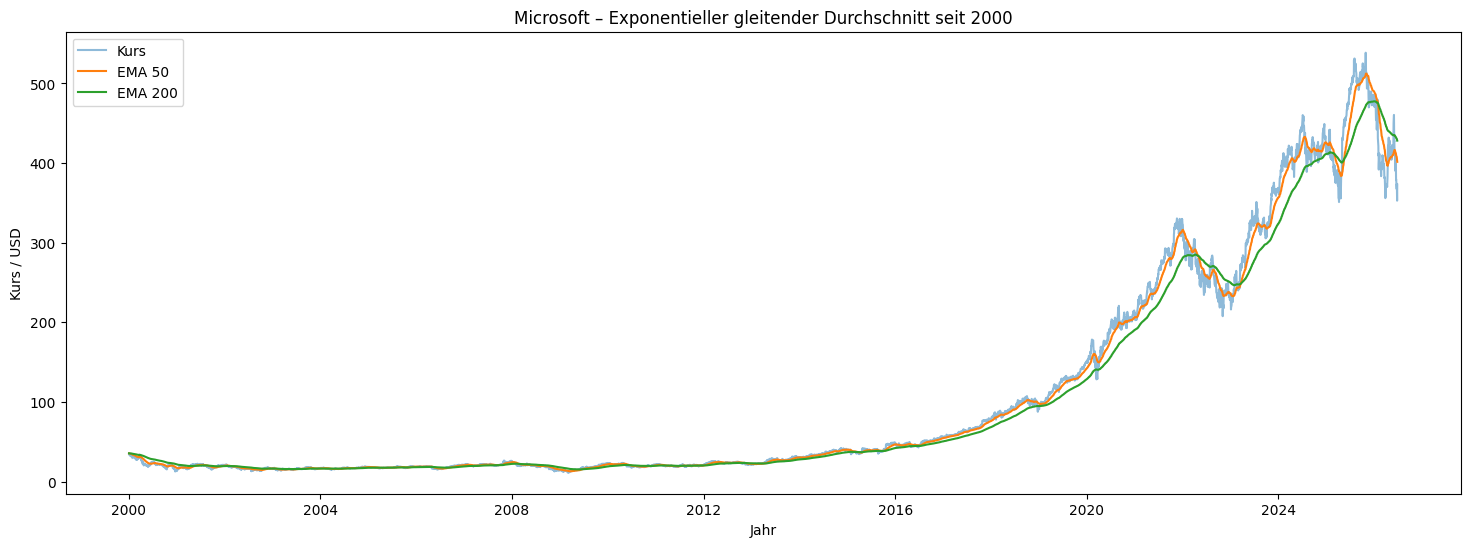

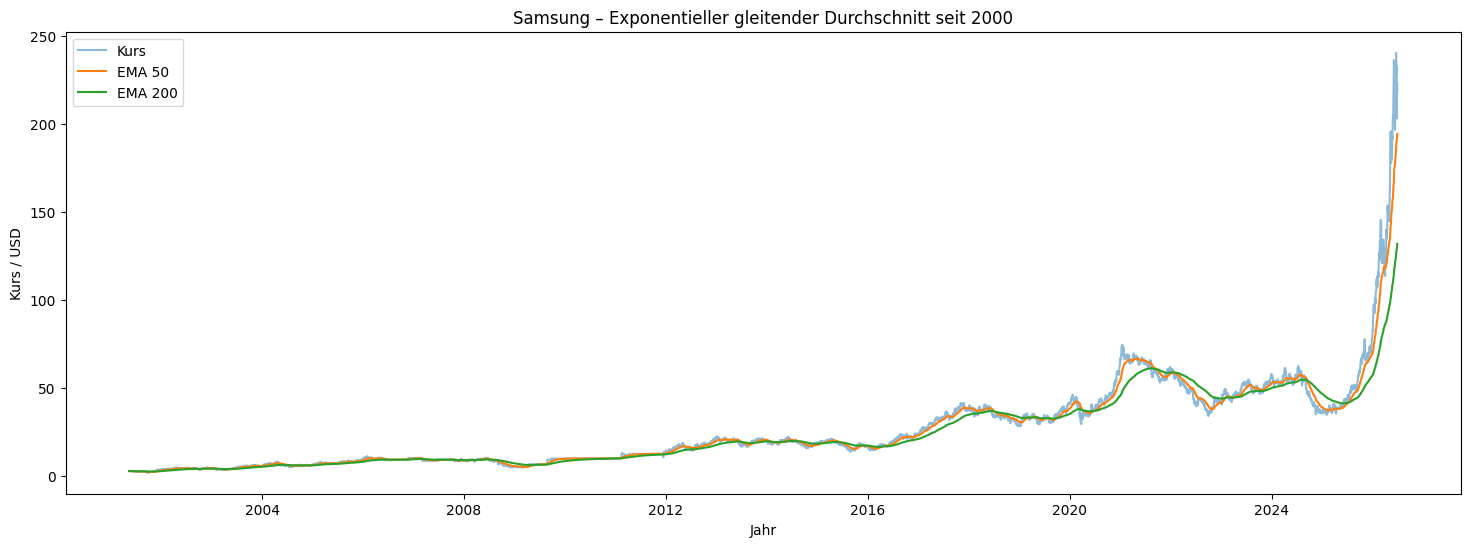

In [12]:
for name, df in daten.items():
    daten[name]["EMA_50"] = daten[name]["Close"].ewm(span=50, adjust=False).mean()
    daten[name]["EMA_200"] = daten[name]["Close"].ewm(span=200, adjust=False).mean()

for name, df in daten.items():
    plt.figure(figsize=(18, 6))
    plt.plot(df["Close"], label="Kurs", alpha=0.5)
    plt.plot(df["EMA_50"], label="EMA 50")
    plt.plot(df["EMA_200"], label="EMA 200")
    plt.title(f"{name} – Exponentieller gleitender Durchschnitt seit 2000")
    plt.xlabel("Jahr")
    plt.ylabel("Kurs / USD")
    plt.legend()
    plt.show()

**Interpretation:** Der exponentielle gleitende Durchschnitt gewichtet jüngere Kurse stärker und reagiert dadurch schneller auf aktuelle Kursbewegungen als der einfache SMA. Trendwechsel werden so früher angezeigt, allerdings auf Kosten von mehr Fehlsignalen in Seitwärtsphasen. Im Vergleich zum SMA folgt der EMA dem Kurs enger, zeigt aber denselben langfristigen Aufwärtstrend für Apple und Microsoft.

#### Verhalten in Krisenzeiten

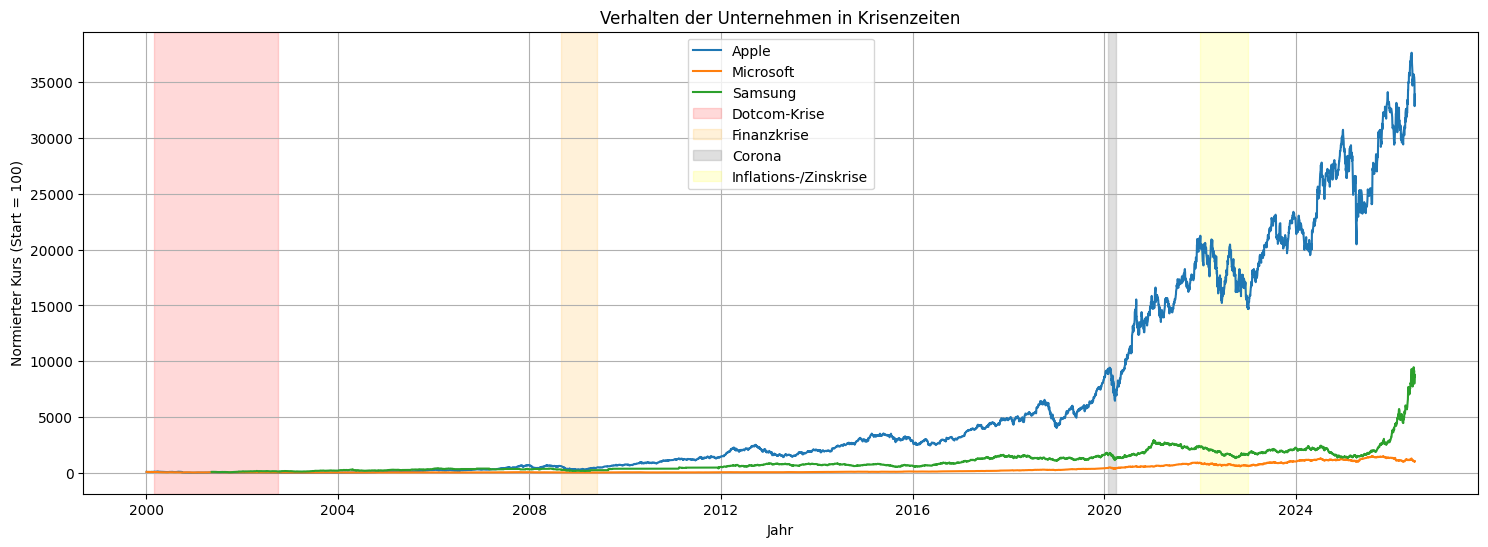

In [13]:
# Alle Aktien auf denselben Startwert normieren
plt.figure(figsize=(18, 6))

for name, df in daten.items():
    normiert = df["Close"] / df["Close"].iloc[0] * 100
    plt.plot(df.index, normiert, label=name)

# Krisen markieren
plt.axvspan(pd.Timestamp("2000-03-01"), pd.Timestamp("2002-10-01"),
            color="red", alpha=0.15, label="Dotcom-Krise")

plt.axvspan(pd.Timestamp("2008-09-01"), pd.Timestamp("2009-06-01"),
            color="orange", alpha=0.15, label="Finanzkrise")

plt.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-01"),
            color="gray", alpha=0.25, label="Corona")

plt.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
            color="yellow", alpha=0.15, label="Inflations-/Zinskrise")

plt.title("Verhalten der Unternehmen in Krisenzeiten")
plt.xlabel("Jahr")
plt.ylabel("Normierter Kurs (Start = 100)")
plt.legend()
plt.grid(True)

plt.show()

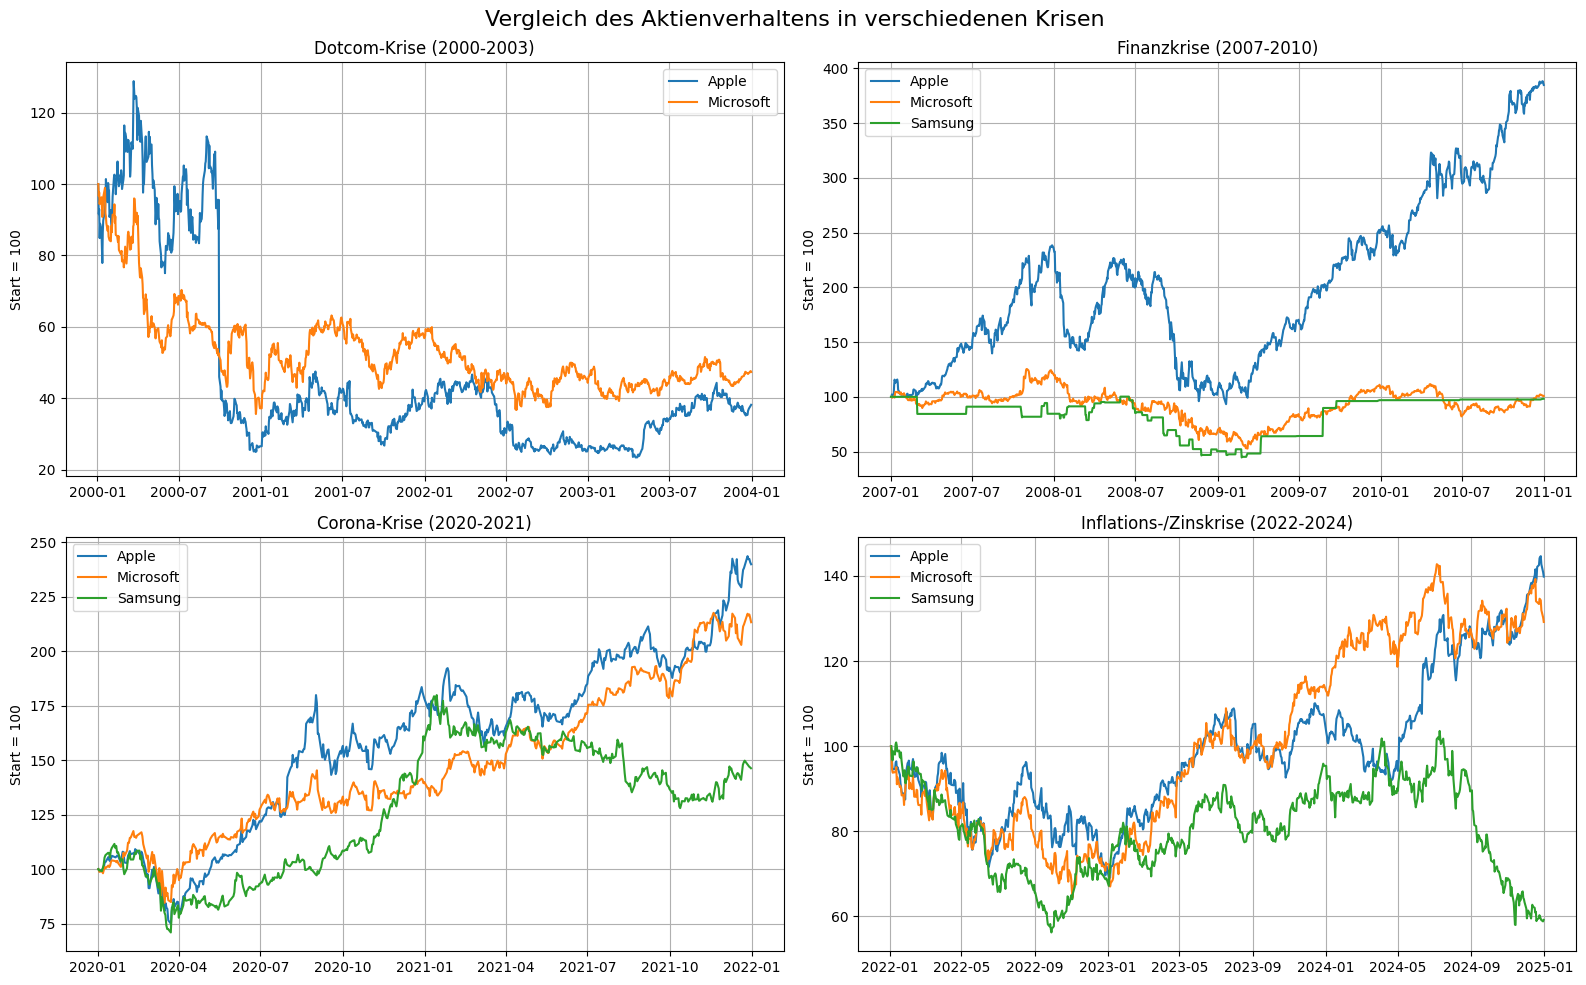

In [14]:
krisen = {
    "Dotcom-Krise (2000-2003)": ("2000-01-01", "2003-12-31"),
    "Finanzkrise (2007-2010)": ("2007-01-01", "2010-12-31"),
    "Corona-Krise (2020-2021)": ("2020-01-01", "2021-12-31"),
    "Inflations-/Zinskrise (2022-2024)": ("2022-01-01", "2024-12-31")
}


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

for ax, (titel, (start, ende)) in zip(axes, krisen.items()):

    for name, df in daten.items():
        if titel == "Dotcom-Krise (2000-2003)" and name == "Samsung":
            continue

        krise_df = df.loc[start:ende]

        normiert = (
            krise_df["Close"]
            / krise_df["Close"].iloc[0]
            * 100
        )

        ax.plot(
            krise_df.index,
            normiert,
            label=name
        )

    ax.set_title(titel)
    ax.set_ylabel("Start = 100")
    ax.grid(True)

for ax in axes:
    ax.legend()

plt.suptitle(
    "Vergleich des Aktienverhaltens in verschiedenen Krisen",
    fontsize=16
)

plt.tight_layout()

plt.show()


In [15]:
krisen = {
    "Dotcom-Krise": ("2000-01-01", "2003-12-31"),
    "Finanzkrise": ("2007-01-01", "2010-12-31"),
    "Corona-Krise": ("2020-01-01", "2021-12-31"),
    "Inflations-/Zinskrise": ("2022-01-01", "2024-12-31")
}

ergebnisse = []

for krise, (start, ende) in krisen.items():

    for name, df in daten.items():
        if krise == "Dotcom-Krise" and name == "Samsung":
            continue

        krise_df = df.loc[start:ende]

        startkurs = krise_df["Close"].iloc[0]
        tiefstkurs = krise_df["Close"].min()
        höchstkurs = krise_df["Close"].max()
        endkurs = krise_df["Close"].iloc[-1]

        verlust = ((tiefstkurs - startkurs) / startkurs) * 100
        gewinn = ((endkurs - startkurs) / startkurs) * 100

        ergebnisse.append([
            krise,
            name,
            round(verlust, 2),
            round(gewinn, 2)
        ])

krisen_df = pd.DataFrame(
    ergebnisse,
    columns=[
        "Krise",
        "Unternehmen",
        "Max. Verlust (%)",
        "Gesamtrendite (%)"
    ]
)

display(krisen_df)

,Krise,Unternehmen,Max. Verlust (%),Gesamtrendite (%)
0,Dotcom-Krise,Apple,-76.56,-61.82
1,Dotcom-Krise,Microsoft,-64.40,-52.62
2,Finanzkrise,Apple,-6.68,284.92
3,Finanzkrise,Microsoft,-47.27,0.81
4,Finanzkrise,Samsung,-55.36,-1.74
5,Corona-Krise,Apple,-25.12,140.00
6,Corona-Krise,Microsoft,-15.46,113.38
7,Corona-Krise,Samsung,-29.08,46.34
8,Inflations-/Zinskrise,Apple,-30.91,39.84
9,Inflations-/Zinskrise,Microsoft,-35.58,29.18


### Interpretation der Krisenanalyse

Die Ergebnisse zeigen deutliche Unterschiede im Verhalten der Unternehmen während wirtschaftlicher Krisen.

- Während der Dotcom-Krise verzeichneten sowohl Apple als auch Microsoft hohe Verluste. Samsung wurde aufgrund fehlender Daten nicht berücksichtigt.
- In der Finanzkrise zeigte Apple trotz zwischenzeitlicher Rückgänge die stärkste Erholung und erzielte mit rund 285 % die höchste Gesamtrendite.
- Während der Corona-Krise entwickelten sich alle drei Unternehmen positiv, wobei Apple erneut die höchste Rendite erzielte.
- In der Inflations- und Zinskrise erwiesen sich Apple und Microsoft als vergleichsweise widerstandsfähig, während Samsung sowohl den höchsten Verlust als auch eine negative Gesamtrendite aufwies.

Insgesamt zeigt Apple die höchste langfristige Wachstumsdynamik und die schnellste Erholung nach Krisen. Microsoft weist die stabilste Entwicklung auf und verzeichnet meist geringere Verluste. Samsung zeigt die stärksten Schwankungen und reagiert empfindlicher auf wirtschaftliche Unsicherheiten.

### Wertentwicklung einer Investition von 1.000 USD (seit 2000)

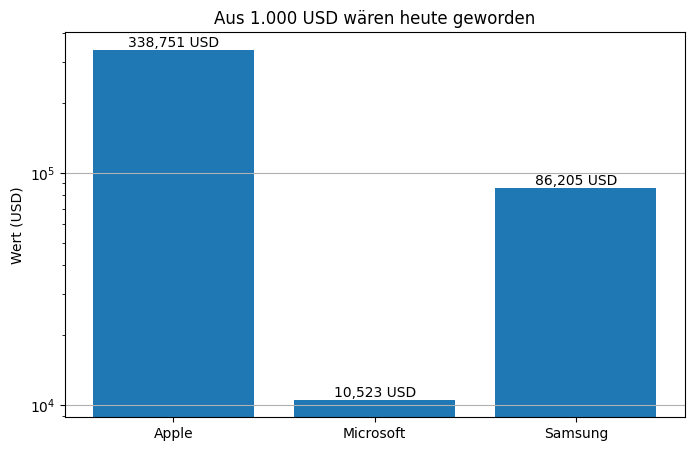

In [16]:
investition = 1000

werte = []

for name, df in daten.items():

    # .dropna(), damit eine unfertige letzte Tageszeile (Yahoo liefert an
    # Wochenenden/Feiertagen für US-Aktien einen NaN-Close) den End- bzw.
    # Startkurs nicht auf NaN setzt – sonst fehlt der Balken im Diagramm
    kurse = df["Close"].dropna()

    startkurs = kurse.iloc[0]
    endkurs = kurse.iloc[-1]

    endwert = investition * (endkurs / startkurs)

    werte.append(endwert)

plt.figure(figsize=(8,5))

bars = plt.bar(daten.keys(), werte)

plt.title("Aus 1.000 USD wären heute geworden")
plt.ylabel("Wert (USD)")
plt.grid(axis="y")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:,.0f} USD",
        ha="center",
        va="bottom"
    )
plt.yscale("log")
plt.show()

**Interpretation:** Die Grafik (logarithmische Skala) zeigt, was aus einer Anfangsinvestition von 1.000 USD im Jahr 2000 bis heute geworden wäre. Apple liegt mit großem Abstand vorn – der Unterschied ist so groß, dass eine logarithmische Achse nötig ist, um alle Unternehmen sinnvoll darzustellen. An zweiter Stelle folgt Samsung, während Microsoft hier die geringste Wertentwicklung aufweist. Das überrascht zunächst, erklärt sich aber durch den Startzeitpunkt: Microsoft notierte Anfang 2000 auf dem Höhepunkt der Dotcom-Blase und damit auf einem vergleichsweise hohen Niveau, sodass das Vielfache vom Start bis heute geringer ausfällt als bei Apple und Samsung. Bezogen auf die durchschnittliche Rendite und die Stabilität (siehe oben) schneidet Microsoft dennoch sehr gut ab – die hier gezeigte Kennzahl hängt stark vom gewählten Einstiegszeitpunkt ab. Insgesamt wird die langfristige Outperformance von Apple greifbar quantifiziert.

### Fallbeispiel Intel: Investition von 1.000 USD seit der 2. Zwischenpräsentation

Als zusätzliches Fallbeispiel wird betrachtet, wie sich eine Investition von 1.000 USD in die Intel-Aktie (INTC) seit der 2. Zwischenpräsentation (04.05.2026) bis zur Abschlusspräsentation entwickelt hätte. Anders als die langfristige Betrachtung seit 2000 zeigt dieser kurze Zeithorizont, wie stark kurzfristige Kursschwankungen eine Investitionsentscheidung beeinflussen.

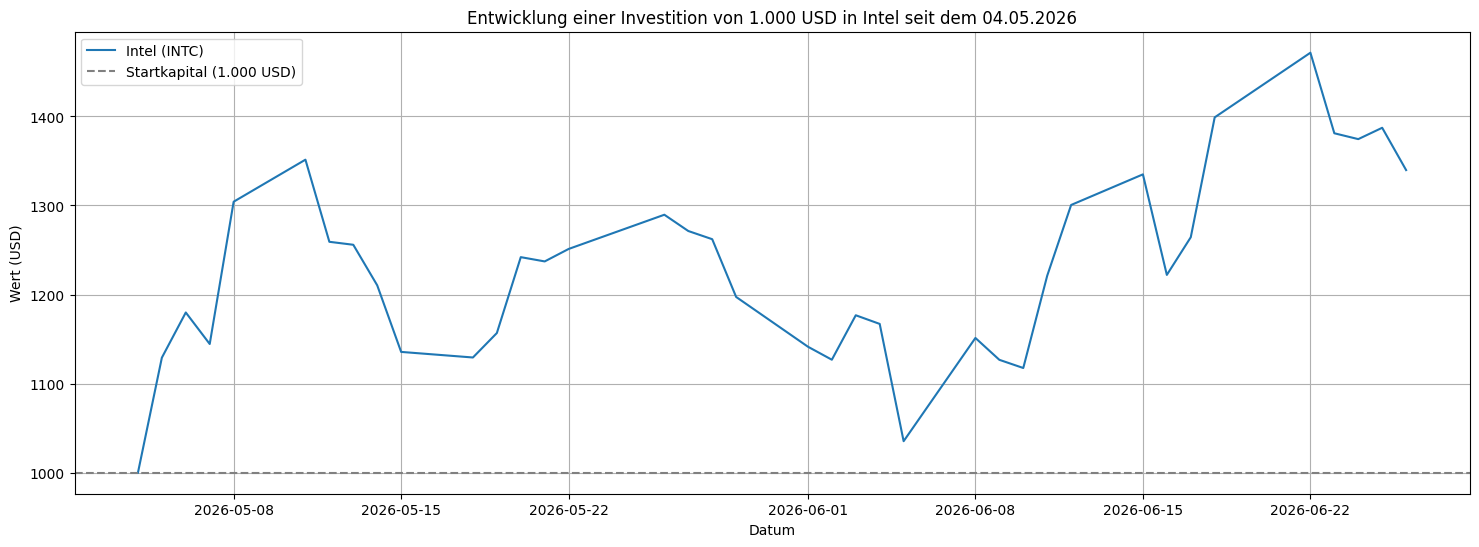

Startkurs (04.05.2026):           95.78 USD
Aktueller Wert der Investition:    1,339.74 USD
Rendite seit 04.05.2026:           +33.97 %


In [17]:
# 1.000 USD in Intel (INTC) investiert am 04.05.2026 (2. Zwischenpräsentation)
intel = yf.Ticker("INTC").history(start="2026-05-04", end=heute)

# unfertige letzte Tageszeile (NaN-Close an Wochenenden/Feiertagen) entfernen,
# damit Start-/Endkurs und der Plot keine NaN-Werte enthalten
intel = intel.dropna(subset=["Close"])

investition = 1000
startkurs = intel["Close"].iloc[0]
intel["Investitionswert"] = investition * (intel["Close"] / startkurs)

endwert = intel["Investitionswert"].iloc[-1]
rendite = (endwert - investition) / investition * 100

plt.figure(figsize=(18, 6))
plt.plot(intel.index, intel["Investitionswert"], label="Intel (INTC)")
plt.axhline(investition, color="gray", linestyle="--", label="Startkapital (1.000 USD)")
plt.title("Entwicklung einer Investition von 1.000 USD in Intel seit dem 04.05.2026")
plt.xlabel("Datum")
plt.ylabel("Wert (USD)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Startkurs (04.05.2026):           {startkurs:,.2f} USD")
print(f"Aktueller Wert der Investition:    {endwert:,.2f} USD")
print(f"Rendite seit 04.05.2026:           {rendite:+.2f} %")

**Interpretation:** Zum aktuellen Datenstand hätte sich die Investition von 1.000 USD in Intel seit dem 04.05.2026 deutlich positiv entwickelt (auf rund 1.390 USD bzw. etwa +39 %). Bereits dieser kurze Zeitraum von wenigen Wochen weist eine erhebliche Kursbewegung auf. Im Gegensatz zur langfristigen Betrachtung seit 2000 hängt das Ergebnis hier stark von der konkreten Marktphase ab – schon kleine Verschiebungen des Ein- oder Ausstiegszeitpunkts können den Ertrag spürbar verändern. Das verdeutlicht das höhere Risiko eines kurzen Anlagehorizonts. Die genauen Werte sind der Ausgabe der vorherigen Zelle zu entnehmen und können sich mit aktualisierten Kursdaten ändern.

## Fazit

Ziel der Analyse war der Vergleich von Apple, Microsoft und Samsung auf Basis ihrer Aktienkurse, um eine Grundlage für Investitionsentscheidungen zu schaffen. Über die untersuchten Kennzahlen ergibt sich ein konsistentes Bild:

- **Kursverlauf & langfristige Wertentwicklung:** Seit 2000 weist Apple das mit Abstand stärkste Wachstum auf. Besonders deutlich wird dies an der Investition von 1.000 USD, deren Endwert bei Apple um ein Vielfaches über dem von Microsoft und Samsung liegt. Die Darstellung war nur auf einer logarithmischen Skala sinnvoll möglich.
- **Rendite:** Apple erzielte im langjährigen Mittel die höchste Durchschnittsrendite, gefolgt von Microsoft; Samsung blieb zurück.
- **Volatilität:** Samsung zeigt die größten Schwankungen und damit das höchste Risiko, während Microsoft am stabilsten verläuft.
- **Gleitende Durchschnitte (SMA/EMA):** Die Trendindikatoren bestätigen den langfristigen Aufwärtstrend von Apple und Microsoft; Schnittpunkte von SMA 50 und SMA 200 markieren Trendwechsel, unter anderem rund um die Krisenzeiträume.
- **Krisenverhalten:** In allen betrachteten Krisen erholte sich Apple am schnellsten und erzielte die höchste Gesamtrendite. Microsoft erwies sich als defensivster Wert mit den geringsten Verlusten, Samsung reagierte am empfindlichsten (negative Gesamtrendite in der Inflations-/Zinskrise).
- **Fallbeispiel Intel:** Über den kurzen Zeitraum seit der 2. Zwischenpräsentation zeigt Intel, wie stark kurzfristige Kursbewegungen das Ergebnis einer Investition prägen – ein kurzer Anlagehorizont ist deutlich stärker von einzelnen Marktphasen abhängig als die langfristige Betrachtung.

**Schlussfolgerung für eine Investitionsentscheidung:** Für ein wachstumsorientiertes Profil ist Apple historisch am attraktivsten, allerdings bei höherer Kursdynamik. Microsoft eignet sich für ein risikoärmeres, defensiveres Profil. Samsung weist das höchste Risiko bei vergleichsweise geringerer Rendite auf.

## Lessons Learned

**Was gut gelaufen ist**
- Die Datenbeschaffung über die Yahoo-Finance-API (`yfinance`) war unkompliziert und liefert aktuelle, frei verfügbare Kursdaten, die bei jedem Ausführen automatisch aktualisiert werden.
- Die Umstellung der Aktien auf ein Dictionary hat den Code schlank gehalten. Weitere Unternehmen lassen sich mit einer Zeile ergänzen, ohne die Analyse anzupassen.
- Die Zusammenarbeit über Git/GitHub mit klarer Aufgabenteilung (Datenaufbereitung vs. Analyse und Visualisierung) hat gut funktioniert.

**Herausforderungen und wie wir damit umgegangen sind**
- **Samsung-Kurse:** Samsung wird an den hier genutzten Börsen nur als GDR (Global Depositary Receipt) gehandelt. 1 GDR entspricht 25 Stammaktien. Das fiel erst durch zu hohe Kurse auf. Lösung: Division der Werte durch 25.
- **Fehlende Daten:** Für Samsung lagen im Zeitraum der Dotcom-Krise keine Daten vor. Wir haben Samsung in diesem Krisenfenster bewusst ausgeschlossen, statt die Vergleichbarkeit zu verfälschen.
- **Währungs-Mix:** Yahoo liefert die Kurse in USD, unser Business Case war ursprünglich in EUR formuliert. Wir haben uns für eine durchgängige USD-Darstellung entschieden, um konsistent zu bleiben und ungenaue Umrechnungen zu vermeiden.
- **Unübersichtliche Plots:** Die tägliche Rendite war als Zeitreihe nicht lesbar; ein gleitender Jahresdurchschnitt (`rolling(365)`) hat die Darstellung deutlich verbessert.

**Überraschende Erkenntnisse**
- Das Ausmaß von Apples Outperformance war überraschend groß. 
Die 1.000-USD-Investition ließ sich nur auf einer logarithmischen Skala sinnvoll darstellen.
- Dass Samsung so abgeschlagen ist, hätten wir nicht erwartet.

**Selbsteinschätzung**
- Wir konnten unseren Business Case sinnvoll mit guten Visualisierungen und Zahlen beantworten.


**Nächste Schritte**
- Zukünftig ist ein Dashboard, mit der Hilfe von `Streamlit`, geplant, bei welchem der Nutzer Parameter wie den Zeitraum und die Aktienauswahl selbst einstellen kann

## Quellen

- **Kursdaten:** Yahoo Finance, abgerufen über die Python-Bibliothek `yfinance` (https://ranaroussi.github.io/yfinance/). Verwendete Ticker: `AAPL` (Apple), `MSFT` (Microsoft), `SMSN.IL` (Samsung GDR), `INTC` (Intel).
- **Samsung-GDR-Umrechnung:** 1 Global Depositary Receipt (GDR) entspricht 25 Stammaktien (Samsung-GDR-Spezifikation, London Stock Exchange).
- **Datierung der betrachteten Krisen:** Dotcom-Krise (2000–2002), globale Finanzkrise (2008–2009), COVID-19-Crash (Februar–März 2020), Inflations-/Zinskrise (2022).
- **Verwendete Bibliotheken:** pandas, Matplotlib, yfinance.